In [1]:
%pip install -U nbformat
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objs as go
df = pd.read_csv("train.csv")


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

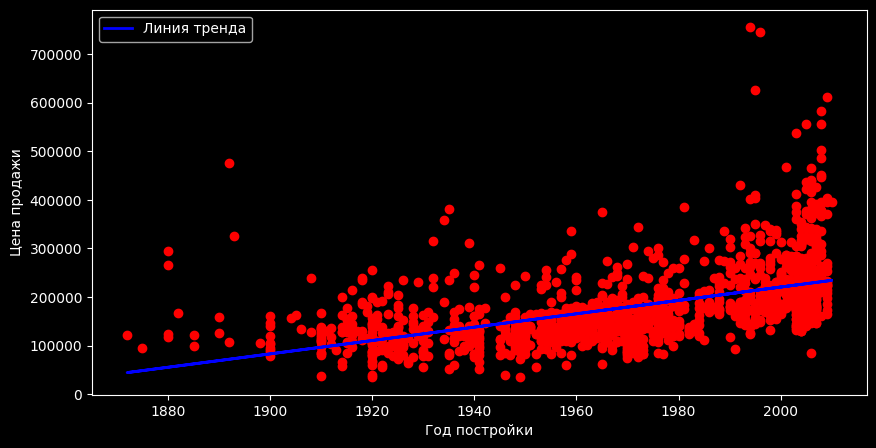

In [77]:
import numpy as np

plt.figure(figsize=(10, 5))

plt.scatter(df["YearBuilt"], df["SalePrice"], color='red')

z = np.polyfit(df["YearBuilt"], df["SalePrice"], 1)
p = np.poly1d(z)

plt.plot(
    df["YearBuilt"],
    p(df["YearBuilt"]),
    color='blue',
    linewidth=2,
    label='Линия тренда'
)

plt.xlabel("Год постройки")
plt.ylabel("Цена продажи")
plt.legend()
plt.show()

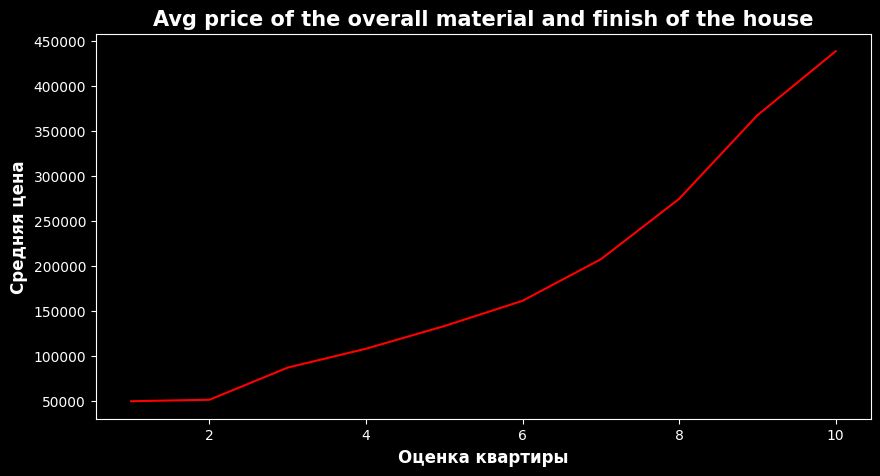

In [78]:
avgprice = df[["OverallQual", "SalePrice"]].groupby("OverallQual").agg("mean")
plt.figure(figsize=(10, 5))
plt.plot(avgprice, color='red')
plt.xlabel("Оценка квартиры", fontweight='bold', fontsize = 12)
plt.ylabel("Средняя цена", fontweight='bold', fontsize = 12)
plt.title("Avg price of the overall material and finish of the house", fontweight='bold', fontsize = 15)
plt.show()

In [79]:
avgprice = df[["BldgType", "SalePrice"]].groupby("BldgType").agg("mean").reset_index()
trace = go.Bar(
                x = avgprice.BldgType,
                y = avgprice.SalePrice,
                marker = dict(color = 'rgba(175, 0, 0, 1)',
                             line=dict(color='rgb(255,255,255)',width=1.5)),
               )

data = trace
layout = go.Layout(xaxis_title = "Type of dwelling", yaxis_title = "Avg price",barmode = "group")
fig = go.Figure(data = data, layout = layout)
fig = go.Figure(fig)
fig.show()

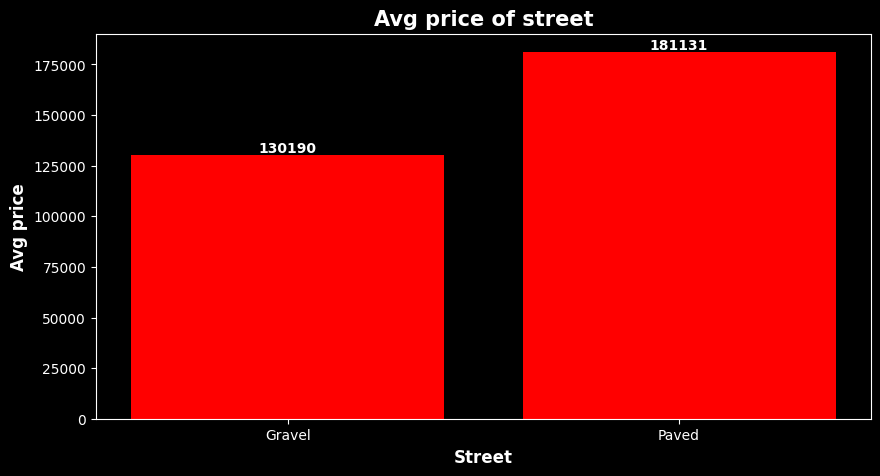

In [80]:
avg_price = df[["Street", "SalePrice"]].groupby("Street").agg("mean")

plt.figure(figsize=(10, 5))
bars = plt.bar(
    avg_price.index,
    avg_price["SalePrice"],
    color='red'
)

plt.bar_label(bars, fmt='%.0f', fontweight='bold')

plt.xticks(
    ticks=avg_price.index,
    labels=["Gravel", "Paved"]
)

plt.xlabel("Street", fontweight='bold', fontsize = 12)
plt.ylabel("Avg price", fontweight='bold', fontsize = 12)
plt.title("Avg price of street", fontweight='bold', fontsize = 15)
plt.show()

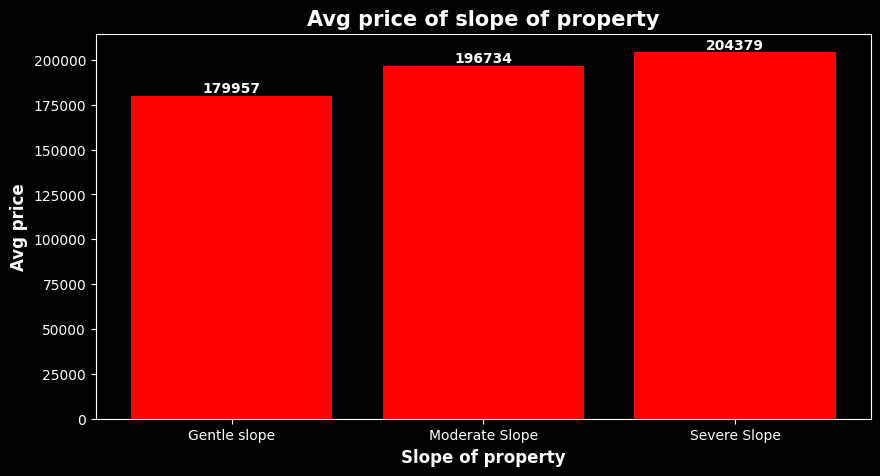

In [81]:
avg_price = df[["LandSlope", "SalePrice"]].groupby("LandSlope").agg("mean")

plt.figure(figsize=(10, 5))
bars = plt.bar(
    avg_price.index,
    avg_price["SalePrice"],
    color='red'
)

plt.bar_label(bars, fmt='%.0f', fontweight='bold')

plt.xticks(
    ticks=avg_price.index,
    labels=["Gentle slope", "Moderate Slope", "Severe Slope"]
)

plt.xlabel("Slope of property", fontweight='bold', fontsize = 12)
plt.ylabel("Avg price", fontweight='bold', fontsize = 12)
plt.title("Avg price of slope of property", fontweight='bold', fontsize = 15)
plt.show()

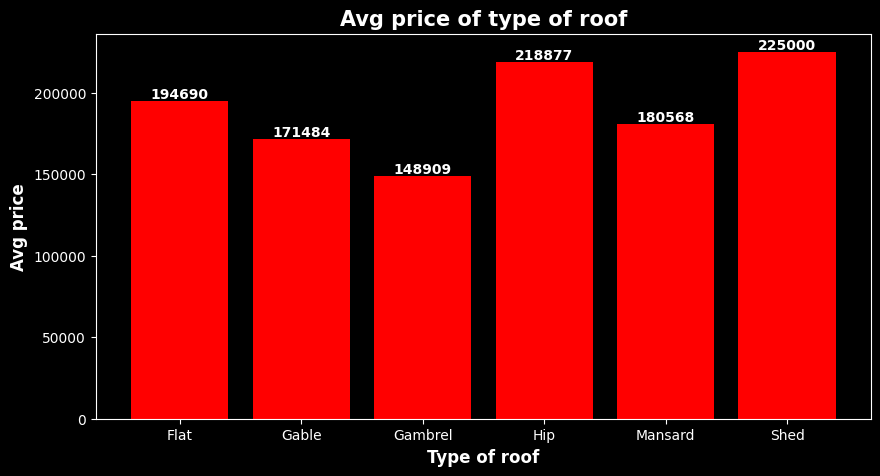

In [82]:
avg_price = df[["RoofStyle", "SalePrice"]].groupby("RoofStyle").agg("mean")

plt.figure(figsize=(10, 5))
bars = plt.bar(
    avg_price.index,
    avg_price["SalePrice"],
    color='red'
)

plt.bar_label(bars, fmt='%.0f', fontweight='bold')

plt.xlabel("Type of roof", fontweight='bold', fontsize = 12)
plt.ylabel("Avg price", fontweight='bold', fontsize = 12)
plt.title("Avg price of type of roof", fontweight='bold', fontsize = 15)
plt.show()

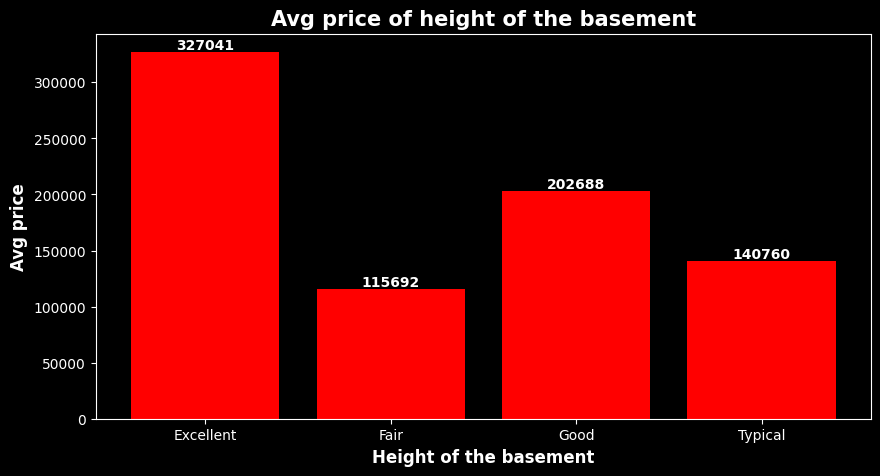

In [84]:
avg_price = df[["BsmtQual", "SalePrice"]].groupby("BsmtQual").agg("mean")

plt.figure(figsize=(10, 5))
bars = plt.bar(
    avg_price.index,
    avg_price["SalePrice"],
    color='red'
)

plt.bar_label(bars, fmt='%.0f', fontweight='bold')

plt.xticks(
    ticks=avg_price.index,
    labels=["Excellent", "Fair", "Good", "Typical", ]
)

plt.xlabel("Height of the basement", fontweight='bold', fontsize = 12)
plt.ylabel("Avg price", fontweight='bold', fontsize = 12)
plt.title("Avg price of height of the basement", fontweight='bold', fontsize = 15)
plt.show()

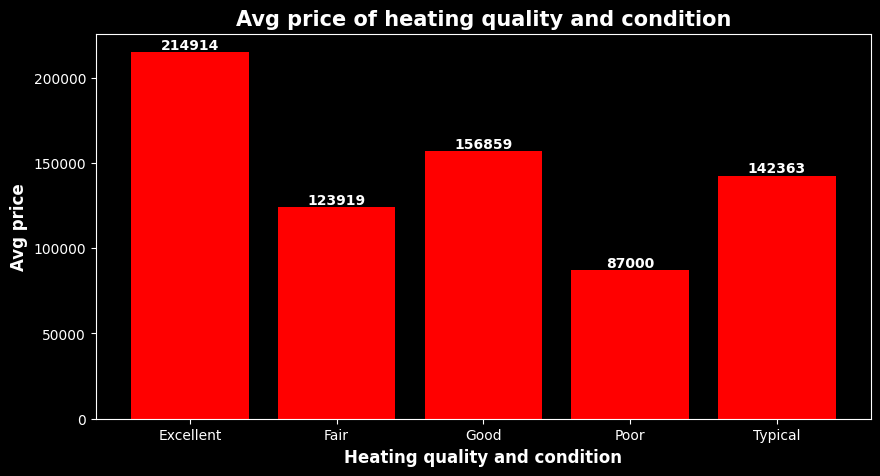

In [85]:
avg_price = df[["HeatingQC", "SalePrice"]].groupby("HeatingQC").agg("mean")

plt.figure(figsize=(10, 5))
bars = plt.bar(
    avg_price.index,
    avg_price["SalePrice"],
    color='red'
)

plt.bar_label(bars, fmt='%.0f', fontweight='bold')

plt.xticks(
    ticks=avg_price.index,
    labels=["Excellent", "Fair", "Good", "Poor", "Typical"]
)

plt.xlabel("Heating quality and condition", fontweight='bold', fontsize = 12)
plt.ylabel("Avg price", fontweight='bold', fontsize = 12)
plt.title("Avg price of heating quality and condition", fontweight='bold', fontsize = 15)
plt.show()

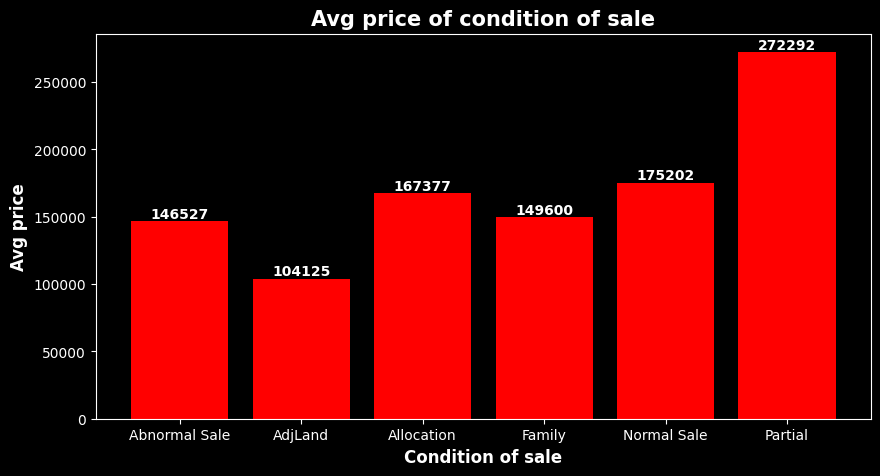

In [86]:
avg_price = df[["SaleCondition", "SalePrice"]].groupby("SaleCondition").agg("mean")

plt.figure(figsize=(10, 5))
bars = plt.bar(
    avg_price.index,
    avg_price["SalePrice"],
    color='red'
)

plt.bar_label(bars, fmt='%.0f', fontweight='bold')

plt.xticks(
    ticks=avg_price.index,
    labels=["Abnormal Sale", "AdjLand", "Allocation", "Family", "Normal Sale", "Partial"]
)

plt.xlabel("Condition of sale", fontweight='bold', fontsize = 12)
plt.ylabel("Avg price", fontweight='bold', fontsize = 12)
plt.title("Avg price of condition of sale", fontweight='bold', fontsize = 15)
plt.show()

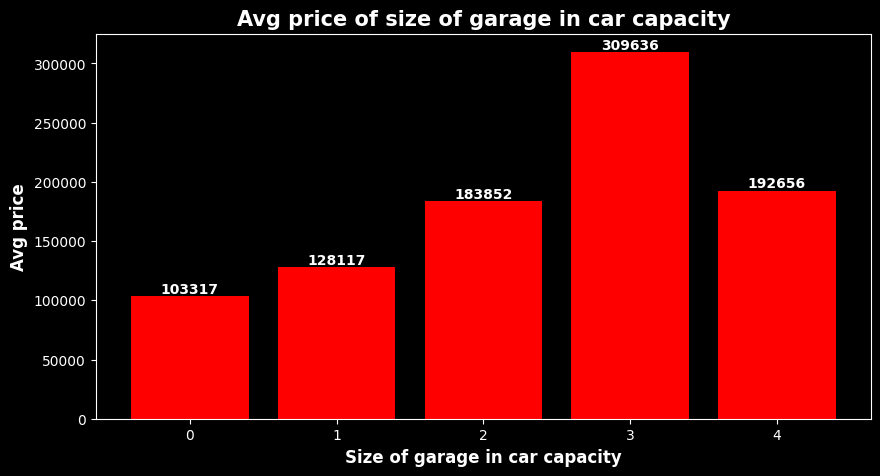

In [87]:
avg_price = df[["GarageCars", "SalePrice"]].groupby("GarageCars").agg("mean")

plt.figure(figsize=(10, 5))
bars = plt.bar(
    avg_price.index,
    avg_price["SalePrice"],
    color='red'
)

plt.bar_label(bars, fmt='%.0f', fontweight='bold')

plt.xlabel("Size of garage in car capacity", fontweight='bold', fontsize = 12)
plt.ylabel("Avg price", fontweight='bold', fontsize = 12)
plt.title("Avg price of size of garage in car capacity", fontweight='bold', fontsize = 15)
plt.show()

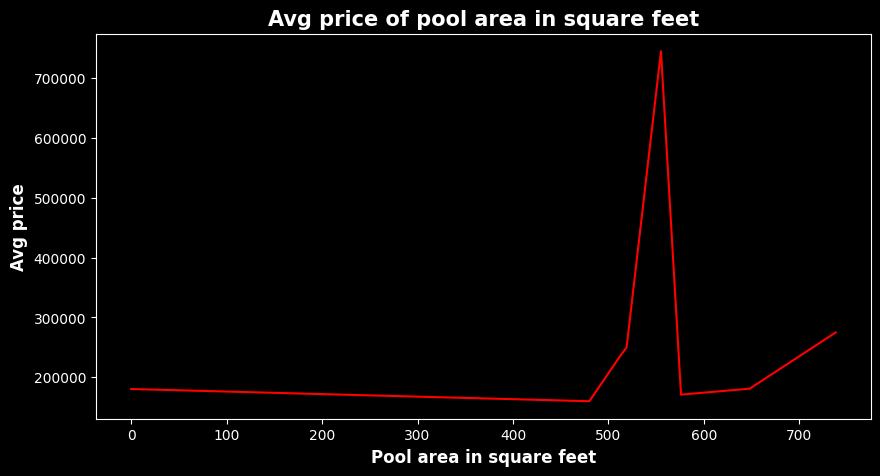

In [72]:
avg_price = df[["PoolArea", "SalePrice"]].groupby("PoolArea").agg("mean")

plt.figure(figsize=(10, 5))
bars = plt.plot(
    avg_price,
    color='red'
)

plt.xlabel("Pool area in square feet", fontweight='bold', fontsize = 12)
plt.ylabel("Avg price", fontweight='bold', fontsize = 12)
plt.title("Avg price of pool area in square feet", fontweight='bold', fontsize = 15)
plt.show()

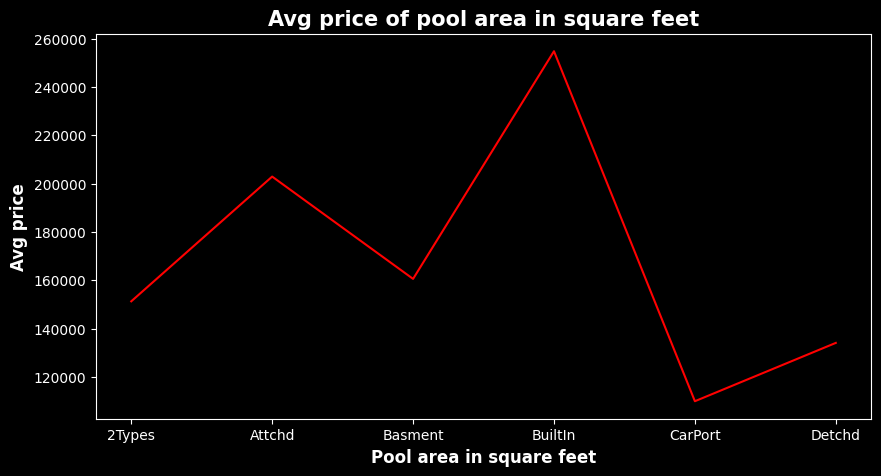

In [88]:
avg_price = df[["GarageType", "SalePrice"]].groupby("GarageType").agg("mean")

plt.figure(figsize=(10, 5))
bars = plt.plot(
    avg_price,
    color='red'
)

plt.xlabel("Pool area in square feet", fontweight='bold', fontsize = 12)
plt.ylabel("Avg price", fontweight='bold', fontsize = 12)
plt.title("Avg price of pool area in square feet", fontweight='bold', fontsize = 15)
plt.show()

Топ показателей, которые влияют на цену (в зависимости от изменения цены внутри показателя):
1. GarageType
2. BsmtQual
3. OverallQual
4. HeatingQC
5. GarageCars
6. RoofStyle
7. SaleCondition
8. Street
9. BldgType
10. YearBuilt